In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE

In [35]:
columns=[
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'
]

In [36]:
train_data= pd.read_csv('/content/KDDTrain+.txt', names=columns)
test_data= pd.read_csv('/content/KDDTest+.txt', names=columns)
print(train_data.shape, test_data.shape)

(125973, 43) (22544, 43)


In [37]:
print(train_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [38]:
print(train_data.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [39]:
print(train_data.describe(include='all'))

            duration protocol_type service    flag     src_bytes  \
count   125973.00000        125973  125973  125973  1.259730e+05   
unique           NaN             3      70      11           NaN   
top              NaN           tcp    http      SF           NaN   
freq             NaN        102689   40338   74945           NaN   
mean       287.14465           NaN     NaN     NaN  4.556674e+04   
std       2604.51531           NaN     NaN     NaN  5.870331e+06   
min          0.00000           NaN     NaN     NaN  0.000000e+00   
25%          0.00000           NaN     NaN     NaN  0.000000e+00   
50%          0.00000           NaN     NaN     NaN  4.400000e+01   
75%          0.00000           NaN     NaN     NaN  2.760000e+02   
max      42908.00000           NaN     NaN     NaN  1.379964e+09   

           dst_bytes           land  wrong_fragment         urgent  \
count   1.259730e+05  125973.000000   125973.000000  125973.000000   
unique           NaN            NaN        

In [40]:
for name, df in [('TRAIN', train_data), ('TEST', test_data)]:
    print(f"\n--- {name} dataset summary ---")
    print(f"Total rows: {df.shape[0]}")
    print(f"Unique attack types: {df['outcome'].nunique()}")
    print("Top 5 attack types:\n", df['outcome'].value_counts().head(5))


--- TRAIN dataset summary ---
Total rows: 125973
Unique attack types: 23
Top 5 attack types:
 outcome
normal       67343
neptune      41214
satan         3633
ipsweep       3599
portsweep     2931
Name: count, dtype: int64

--- TEST dataset summary ---
Total rows: 22544
Unique attack types: 38
Top 5 attack types:
 outcome
normal          9711
neptune         4657
guess_passwd    1231
mscan            996
warezmaster      944
Name: count, dtype: int64


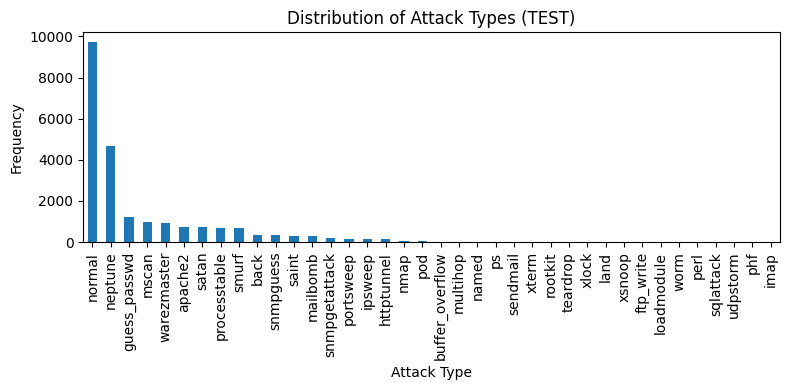

In [41]:
plt.figure(figsize=(8,4))
df['outcome'].value_counts().plot(kind='bar')
plt.title(f"Distribution of Attack Types ({name})")
plt.xlabel("Attack Type")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [42]:
#identifying the types
categorical = ['protocol_type', 'service', 'flag']
binary = ['land', 'logged_in', 'is_host_login', 'is_guest_login', 'root_shell', 'su_attempted']
numerical = [col for col in columns if col not in (categorical + binary + ['outcome', 'level'])]
print("Categorical features:", categorical)
print("Binary features:", binary)
print("Numerical features:", numerical)

Categorical features: ['protocol_type', 'service', 'flag']
Binary features: ['land', 'logged_in', 'is_host_login', 'is_guest_login', 'root_shell', 'su_attempted']
Numerical features: ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [43]:
print("\nMissing values per column:\n", train_data.isnull().sum())
print("\nNumber of duplicate rows:", train_data.duplicated().sum())


Missing values per column:
 duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate 

In [44]:
print("\nMissing values per column:\n", test_data.isnull().sum())
print("\nNumber of duplicate rows:", test_data.duplicated().sum())


Missing values per column:
 duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate 

In [45]:
#handling missing values
train_data=train_data.fillna(0).drop_duplicates()
test_data=test_data.fillna(0).drop_duplicates()

In [46]:
train_data=pd.get_dummies(train_data, columns=categorical)
test_data=pd.get_dummies(test_data, columns=categorical)
train_data,test_data=train_data.align(test_data, join='outer', axis=1, fill_value=0)

In [47]:
encoded_columns = [col for col in train_data.columns if col.startswith('protocol_type_')
                   or col.startswith('service_')
                   or col.startswith('flag_')]

print("Encoded columns:")
print(train_data[encoded_columns].head())

Encoded columns:
   flag_OTH  flag_REJ  flag_RSTO  flag_RSTOS0  flag_RSTR  flag_S0  flag_S1  \
0     False     False      False        False      False    False    False   
1     False     False      False        False      False    False    False   
2     False     False      False        False      False     True    False   
3     False     False      False        False      False    False    False   
4     False     False      False        False      False    False    False   

   flag_S2  flag_S3  flag_SF  ...  service_telnet  service_tftp_u  \
0    False    False     True  ...           False           False   
1    False    False     True  ...           False           False   
2    False    False    False  ...           False           False   
3    False    False     True  ...           False           False   
4    False    False     True  ...           False           False   

   service_tim_i  service_time  service_urh_i  service_urp_i  service_uucp  \
0          False     

In [48]:
encoded_columns = [col for col in test_data.columns if col.startswith('protocol_type_')
                   or col.startswith('service_')
                   or col.startswith('flag_')]

print("Encoded columns:")
print(test_data[encoded_columns].head())

Encoded columns:
   flag_OTH  flag_REJ  flag_RSTO  flag_RSTOS0  flag_RSTR  flag_S0  flag_S1  \
0     False      True      False        False      False    False    False   
1     False      True      False        False      False    False    False   
2     False     False      False        False      False    False    False   
3     False     False      False        False      False    False    False   
4     False     False       True        False      False    False    False   

   flag_S2  flag_S3  flag_SF  ...  service_telnet  service_tftp_u  \
0    False    False    False  ...           False           False   
1    False    False    False  ...           False           False   
2    False    False     True  ...           False           False   
3    False    False     True  ...           False           False   
4    False    False    False  ...            True           False   

   service_tim_i  service_time  service_urh_i  service_urp_i  service_uucp  \
0          False     

In [49]:
scaler=MinMaxScaler()
train_data[numerical]=scaler.fit_transform(train_data[numerical])
test_data[numerical]=scaler.transform(test_data[numerical])

In [50]:
print("Data after normalization:\n", train_data[numerical].head())

Data after normalization:
    duration     src_bytes     dst_bytes  wrong_fragment  urgent  hot  \
0       0.0  3.558064e-07  0.000000e+00             0.0     0.0  0.0   
1       0.0  1.057999e-07  0.000000e+00             0.0     0.0  0.0   
2       0.0  0.000000e+00  0.000000e+00             0.0     0.0  0.0   
3       0.0  1.681203e-07  6.223962e-06             0.0     0.0  0.0   
4       0.0  1.442067e-07  3.206260e-07             0.0     0.0  0.0   

   num_failed_logins  num_compromised  num_root  num_file_creations  ...  \
0                0.0              0.0       0.0                 0.0  ...   
1                0.0              0.0       0.0                 0.0  ...   
2                0.0              0.0       0.0                 0.0  ...   
3                0.0              0.0       0.0                 0.0  ...   
4                0.0              0.0       0.0                 0.0  ...   

   dst_host_count  dst_host_srv_count  dst_host_same_srv_rate  \
0        0.588235 

In [51]:
X_train = train_data.drop(columns=['outcome', 'level'])
y_train = train_data['outcome'].apply(lambda x: 0 if x == 'normal' else 1)

In [52]:
X_test = test_data.drop(columns=['outcome', 'level'])
y_test = test_data['outcome'].apply(lambda x: 0 if x == 'normal' else 1)

In [53]:
print("Normal vs Attack in Training Set:\n", y_train.value_counts())
print("Normal vs Attack in Test Set:\n", y_test.value_counts())

Normal vs Attack in Training Set:
 outcome
0    67343
1    58630
Name: count, dtype: int64
Normal vs Attack in Test Set:
 outcome
1    12833
0     9711
Name: count, dtype: int64


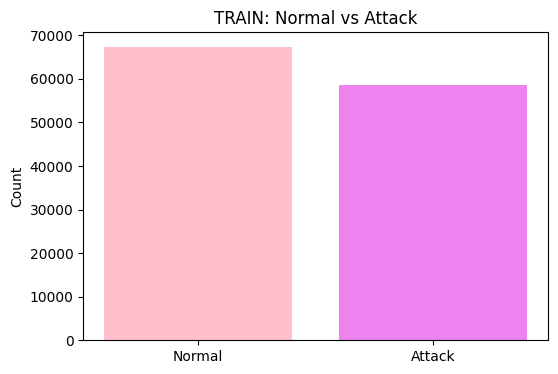

In [54]:
plt.figure(figsize=(6,4))
plt.bar(['Normal','Attack'], [(y_train==0).sum(), (y_train==1).sum()],color=['pink','violet'])
plt.title('TRAIN: Normal vs Attack')
plt.ylabel('Count')
plt.show()

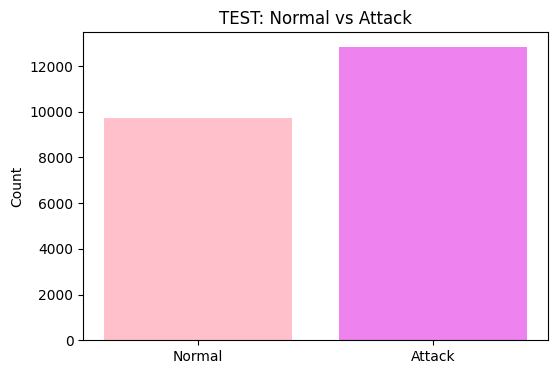

In [55]:
plt.figure(figsize=(6,4))
plt.bar(['Normal','Attack'], [(y_test==0).sum(), (y_test==1).sum()],color=['pink','violet'])
plt.title('TEST: Normal vs Attack')
plt.ylabel('Count')
plt.show()

In [56]:
print("Train columns count:", len(X_train.columns))
print("Test columns count:", len(X_test.columns))

Train columns count: 122
Test columns count: 122


In [57]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
print("Resampled training set:", X_train.shape, y_train.value_counts())

Resampled training set: (134686, 122) outcome
0    67343
1    67343
Name: count, dtype: int64


In [58]:
selector = VarianceThreshold(threshold=0.001)
X_train_sel = selector.fit_transform(X_train)
X_test_sel = selector.transform(X_test)

In [59]:
def tune_model(model, param_dist, X, y):
    search = RandomizedSearchCV(
        model, param_dist,
        n_iter=20, cv=3,
        scoring="accuracy", n_jobs=-1, random_state=42
    )
    search.fit(X, y)
    print(f"Best params for {model.__class__.__name__}:", search.best_params_)
    return search.best_estimator_

In [60]:
rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

In [61]:
gb_params = {
    'n_estimators': [200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3],
    'subsample': [0.8, 1.0]
}

In [62]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Random Forest
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

# Gradient Boosting
best_gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

# XGBoost
best_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)


=== Training & Evaluating: Logistic Regression ===
Accuracy: 0.7550124201561391
Confusion Matrix:
 [[8989  722]
 [4801 8032]]
Classification Report:
               precision    recall  f1-score   support

           0     0.6518    0.9257    0.7650      9711
           1     0.9175    0.6259    0.7442     12833

    accuracy                         0.7550     22544
   macro avg     0.7847    0.7758    0.7546     22544
weighted avg     0.8031    0.7550    0.7531     22544


=== Training & Evaluating: Random Forest ===
Accuracy: 0.7804293825408091
Confusion Matrix:
 [[9453  258]
 [4692 8141]]
Classification Report:
               precision    recall  f1-score   support

           0     0.6683    0.9734    0.7925      9711
           1     0.9693    0.6344    0.7669     12833

    accuracy                         0.7804     22544
   macro avg     0.8188    0.8039    0.7797     22544
weighted avg     0.8396    0.7804    0.7779     22544


=== Training & Evaluating: Decision Tree ===
Accu

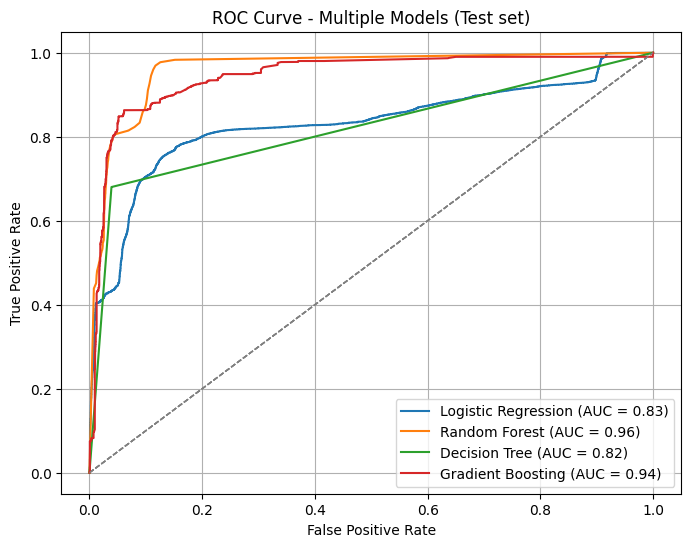

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Decision Tree': DecisionTreeClassifier(),
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=100),
}
results =[]
plt.figure(figsize=(8,6))
for name, model in models.items():
    print(f"\n=== Training & Evaluating: {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))
    if hasattr(model, "predict_proba"):
     y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc=auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    results.append({"model": name, "accuracy": acc, "auc": roc_auc})
    plt.plot([0,1],[0,1], linestyle='--', lw=1, color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multiple Models (Test set)")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Model comparison:
                  model  accuracy       auc
3    Gradient Boosting  0.806512  0.944463
2        Decision Tree  0.800923  0.820578
1        Random Forest  0.780429  0.961301
0  Logistic Regression  0.755012  0.830801


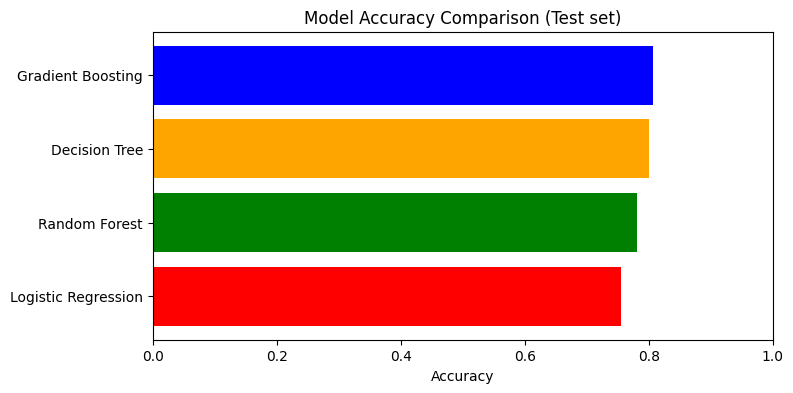

In [ ]:
res_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
print("\nModel comparison:\n", res_df)
plt.figure(figsize=(8,4))
plt.barh(res_df['model'], res_df['accuracy'],color=['blue','orange','green','red'])
plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison (Test set)")
plt.xlim(0,1)
plt.gca().invert_yaxis() # To display the highest accuracy at the top
plt.show()

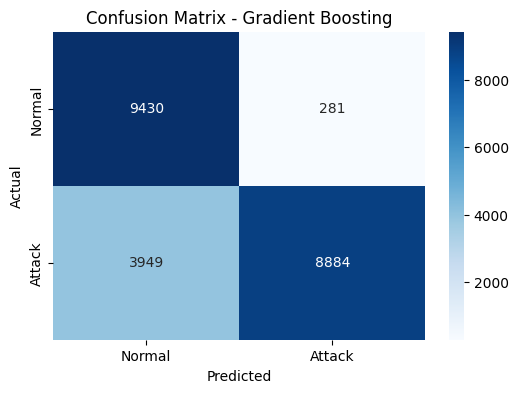

Confusion Matrix Accuracy (Gradient Boosting): 81.24%


In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Pick best performing model (Gradient Boosting in your case)
best_model = models['Gradient Boosting']
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', # Changed cmap to 'Blues'
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Accuracy from confusion matrix
accuracy_from_cm = (cm[0,0] + cm[1,1]) / cm.sum()
print(f"Confusion Matrix Accuracy (Gradient Boosting): {accuracy_from_cm * 100:.2f}%")

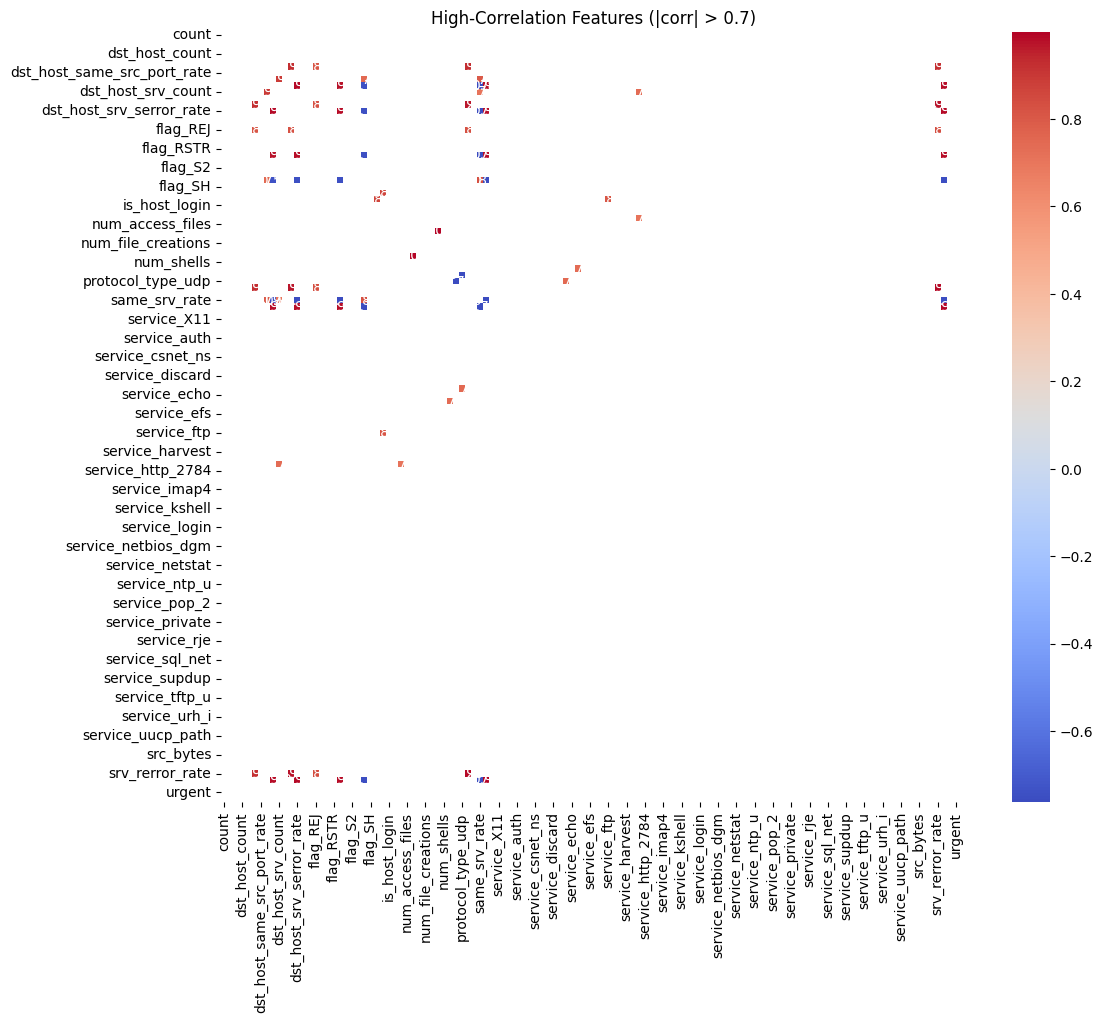

In [67]:
plt.figure(figsize=(12, 10))
corr = X_train.corr()

# Filter correlations above threshold
high_corr = corr[(corr.abs() > 0.7) & (corr != 1.0)]

sns.heatmap(high_corr, cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
plt.title("High-Correlation Features (|corr| > 0.7)")
plt.show()

In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

metrics = []

for name, model in models.items():
    # Training accuracy
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Testing accuracy
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Precision, Recall, F1
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    # AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    auc_val = roc_auc_score(y_test, y_score)

    metrics.append([name, train_acc, test_acc, precision, recall, f1, auc_val])

# Convert to dataframe
metrics_df = pd.DataFrame(metrics, columns=["Model", "Train Acc", "Test Acc", "Precision", "Recall", "F1-score", "AUC"])

# Show table nicely
print(metrics_df.to_markdown(index=False))

| Model               |   Train Acc |   Test Acc |   Precision |   Recall |   F1-score |      AUC |
|:--------------------|------------:|-----------:|------------:|---------:|-----------:|---------:|
| Logistic Regression |    0.972766 |   0.754613 |    0.917152 | 0.625419 |   0.743699 | 0.825256 |
| Random Forest       |    0.999948 |   0.768497 |    0.968381 | 0.613341 |   0.751014 | 0.961201 |
| Decision Tree       |    0.999948 |   0.809395 |    0.958925 | 0.694927 |   0.805856 | 0.827982 |
| Gradient Boosting   |    0.999777 |   0.812367 |    0.96934  | 0.692278 |   0.80771  | 0.948585 |
| XGBoost             |    0.999829 |   0.800035 |    0.969437 | 0.669836 |   0.792258 | 0.969855 |
